In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kaggle (1).json to kaggle (1).json


In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle (1).json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)
print("Kaggle ready!")

Kaggle ready!


In [ ]:
!kaggle datasets list

ref                                                           title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
laveshjadon/ai-impact-on-students                             Impact of Ai on Students                               1187170  2026-05-10 23:12:10.070000          10879        266                1  
kulkarniparth09/fifa-world-cup-complete-dataset-19302026      FIFA World Cup Complete Dataset: 1930–2026               11953  2026-06-07 06:29:15.677000           1382         37                1  
sateasinpedas/global-geo-economic-stress-indicators           Global Geo-Economic Stress Indicators                  1105907  2026-06-07 15:37:49.907000            840         25                1  
anujsaha01

In [ ]:
!kaggle datasets download -d fanconic/skin-cancer-malignant-vs-benign
!unzip -q skin-cancer-malignant-vs-benign.zip -d skin_cancer
print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/fanconic/skin-cancer-malignant-vs-benign
License(s): unknown
100% 325M/325M [00:05<00:00, 59.8MB/s]

Dataset ready!


In [23]:
import os

# Count images in each folder
for folder in os.listdir('skin_cancer'):
    path = f'skin_cancer/{folder}'
    if os.path.isdir(path):
        for subfolder in os.listdir(path):
            subpath = f'{path}/{subfolder}'
            if os.path.isdir(subpath):
                count = len(os.listdir(subpath))
                print(f'{folder}/{subfolder}: {count} images')

train/malignant: 1197 images
train/benign: 1440 images
test/malignant: 300 images
test/benign: 360 images


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_dir = 'skin_cancer/train'
test_dir = 'skin_cancer/test'
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(100, 100),
    batch_size=32,
    class_mode='binary'
)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(100, 100),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 2637 images belonging to 2 classes.
Found 660 images belonging to 2 classes.


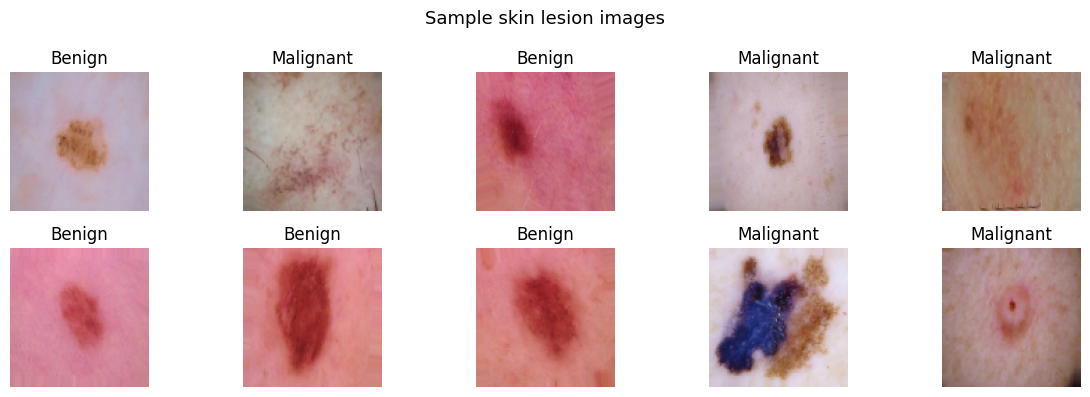

In [ ]:
import matplotlib.pyplot as plt
images, labels = next(train_data)
class_names = ['Benign', 'Malignant']
plt.figure(figsize=(12,4))
for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.imshow(images[i])
  plt.title(class_names[int(labels[i])])
  plt.axis('off')
plt.suptitle('Sample skin lesion images', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(100, 100, 3)),

    # Block 1
    keras.layers.Conv2D(32, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    # Block 2
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    # Block 3
    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    # Classify
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,731,905 (6.61 MB)

 Trainable params: 1,731,905 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    epochs=15,
    validation_data=test_data,
    verbose=1
)

Epoch 1/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 38s 433ms/step - accuracy: 0.6818 - loss: 0.5752 - val_accuracy: 0.7727 - val_loss: 0.5388
Epoch 2/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 35s 424ms/step - accuracy: 0.7751 - loss: 0.4676 - val_accuracy: 0.7697 - val_loss: 0.4557
Epoch 3/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 36s 439ms/step - accuracy: 0.7812 - loss: 0.4479 - val_accuracy: 0.7970 - val_loss: 0.3895
Epoch 4/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 35s 425ms/step - accuracy: 0.8058 - loss: 0.4173 - val_accuracy: 0.8106 - val_loss: 0.3989
Epoch 5/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 38s 459ms/step - accuracy: 0.8013 - loss: 0.4177 - val_accuracy: 0.7545 - val_loss: 0.4592
Epoch 6/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 445ms/step - accuracy: 0.7941 - loss: 0.4209 - val_accuracy: 0.8076 - val_loss: 0.4058
Epoch 7/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 442ms/step - accuracy: 0.8165 - loss: 0.3937 - val_accuracy: 0.7561 - val_loss: 0.4424
Epoch 8/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 36s 433ms/step - accuracy: 0.8127 - loss: 0.3929 - val_accu

In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(test_data, verbose=0)
print("Test accuracy:", round(test_acc, 4))

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Get predictions
test_data.reset()
y_pred_probs = model.predict(test_data, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = test_data.classes

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))

Test accuracy: 0.8333

Confusion Matrix:
[[286  74]
 [ 36 264]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.89      0.79      0.84       360
   Malignant       0.78      0.88      0.83       300

    accuracy                           0.83       660
   macro avg       0.83      0.84      0.83       660
weighted avg       0.84      0.83      0.83       660



/tmp/ipykernel_1520/1377822124.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label = class_names[int(predictions[i] > 0.5)]


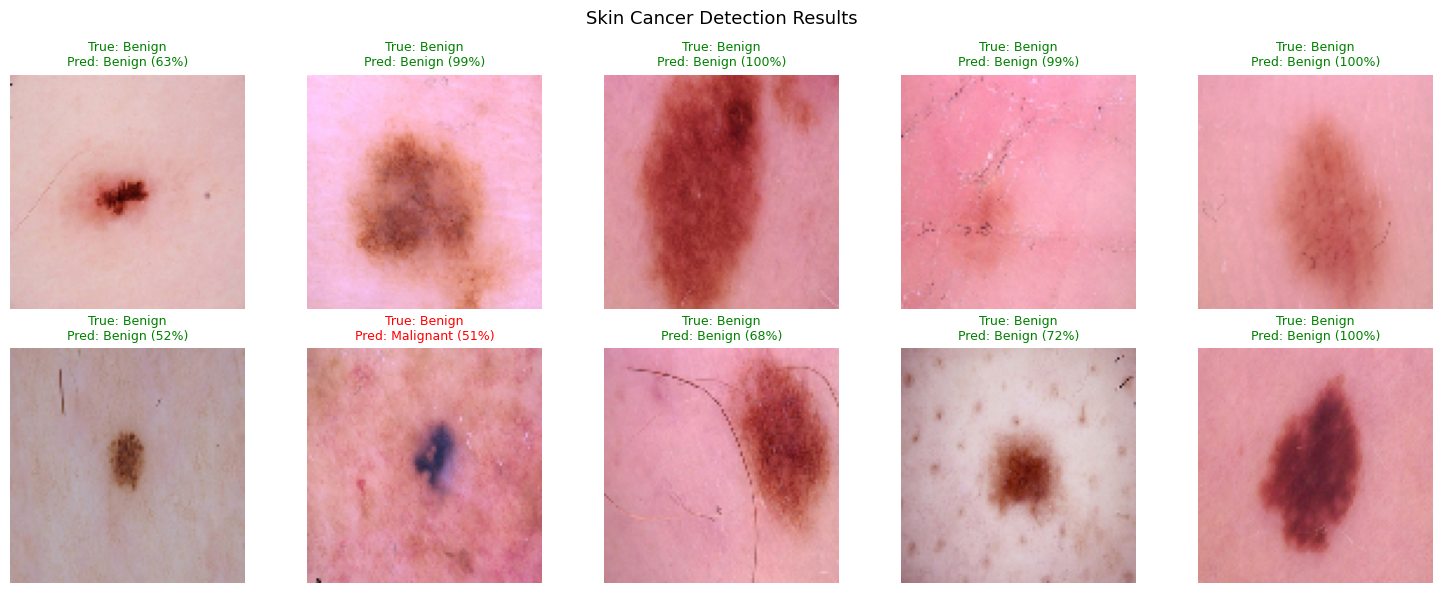

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

test_data.reset()
images, labels = next(test_data)
predictions = model.predict(images, verbose=0)

class_names = ['Benign', 'Malignant']

plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i])
    true_label = class_names[int(labels[i])]
    pred_label = class_names[int(predictions[i] > 0.5)]
    confidence = predictions[i][0] if predictions[i] > 0.5 else 1 - predictions[i][0]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence*100:.0f}%)", fontsize=9, color=color)
    plt.axis('off')
plt.suptitle("Skin Cancer Detection Results", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')